<a href="https://colab.research.google.com/github/MONISHA-003/ds_casestudy/blob/main/DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = {
    "Employee_ID": ["E101","E102","E103","E104","E105","E106","E107","E108","E109","E110",
                    "E111","E112","E113","E114","E115","E116","E117","E118","E119","E120"],

    "Age": [34,29,41,37,45,31,28,39,50,36,33,42,30,27,46,38,35,44,32,40],

    "Department": ["HR","IT","Finance","IT","HR","Sales","Sales","Finance","HR","IT",
                   "Sales","Finance","HR","IT","Sales","HR","Finance","IT","Sales","HR"],

    "YearsAtCompany": [10,5,3,7,12,2,1,8,15,6,4,9,3,2,13,7,5,11,4,8],

    "YearsSinceLastPromotion": [4,1,5,2,6,1,0,3,7,2,3,4,2,1,8,3,2,6,3,5],

    "Attrition": ["Yes","No","Yes","No","Yes","No","No","No","Yes","No",
                  "Yes","No","No","No","Yes","No","No","Yes","No","Yes"]
}

df = pd.DataFrame(data)

print("Dataset Loaded Successfully!\n")
print(df.head())

Dataset Loaded Successfully!

  Employee_ID  Age Department  YearsAtCompany  YearsSinceLastPromotion  \
0        E101   34         HR              10                        4   
1        E102   29         IT               5                        1   
2        E103   41    Finance               3                        5   
3        E104   37         IT               7                        2   
4        E105   45         HR              12                        6   

  Attrition  
0       Yes  
1        No  
2       Yes  
3        No  
4       Yes  


In [3]:

df["Tenure_Months"] = df["YearsAtCompany"] * 12
df["Promo_Gap_Months"] = df["YearsSinceLastPromotion"] * 12

df["Is_Promotion_Stagnant"] = (df["Promo_Gap_Months"] > 36).astype(int)

df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

df["Risk_Status"] = np.where(
    (df["Attrition"] == 1) & (df["Is_Promotion_Stagnant"] == 1),
    "High Risk",
    "Low Risk"
)

print("\nEngineered Dataset:\n")
print(df.head())


Engineered Dataset:

  Employee_ID  Age Department  YearsAtCompany  YearsSinceLastPromotion  \
0        E101   34         HR              10                        4   
1        E102   29         IT               5                        1   
2        E103   41    Finance               3                        5   
3        E104   37         IT               7                        2   
4        E105   45         HR              12                        6   

   Attrition  Tenure_Months  Promo_Gap_Months  Is_Promotion_Stagnant  \
0          1            120                48                      1   
1          0             60                12                      0   
2          1             36                60                      1   
3          0             84                24                      0   
4          1            144                72                      1   

  Risk_Status  
0   High Risk  
1    Low Risk  
2   High Risk  
3    Low Risk  
4   High Risk  


In [4]:
print("\nSample Engineered Table:\n")
print(df[["Employee_ID","Age","Tenure_Months","Promo_Gap_Months",
          "Is_Promotion_Stagnant","Attrition","Risk_Status"]].head())


Sample Engineered Table:

  Employee_ID  Age  Tenure_Months  Promo_Gap_Months  Is_Promotion_Stagnant  \
0        E101   34            120                48                      1   
1        E102   29             60                12                      0   
2        E103   41             36                60                      1   
3        E104   37             84                24                      0   
4        E105   45            144                72                      1   

   Attrition Risk_Status  
0          1   High Risk  
1          0    Low Risk  
2          1   High Risk  
3          0    Low Risk  
4          1   High Risk  


In [5]:
print("\nAggregate Statistics:\n")

print("Total Employees:", len(df))
print("Average Tenure (Months):", df["Tenure_Months"].mean())
print("Maximum Tenure (Months):", df["Tenure_Months"].max())
print("Minimum Tenure (Months):", df["Tenure_Months"].min())
print("Average Promotion Gap (Months):", df["Promo_Gap_Months"].mean())

stagnant_percent = (df["Is_Promotion_Stagnant"].mean()) * 100
attrition_rate = (df["Attrition"].mean()) * 100

print("Employees with Promotion Stagnation (%):", stagnant_percent)
print("Attrition Rate (%):", attrition_rate)


Aggregate Statistics:

Total Employees: 20
Average Tenure (Months): 81.0
Maximum Tenure (Months): 180
Minimum Tenure (Months): 12
Average Promotion Gap (Months): 40.8
Employees with Promotion Stagnation (%): 40.0
Attrition Rate (%): 40.0


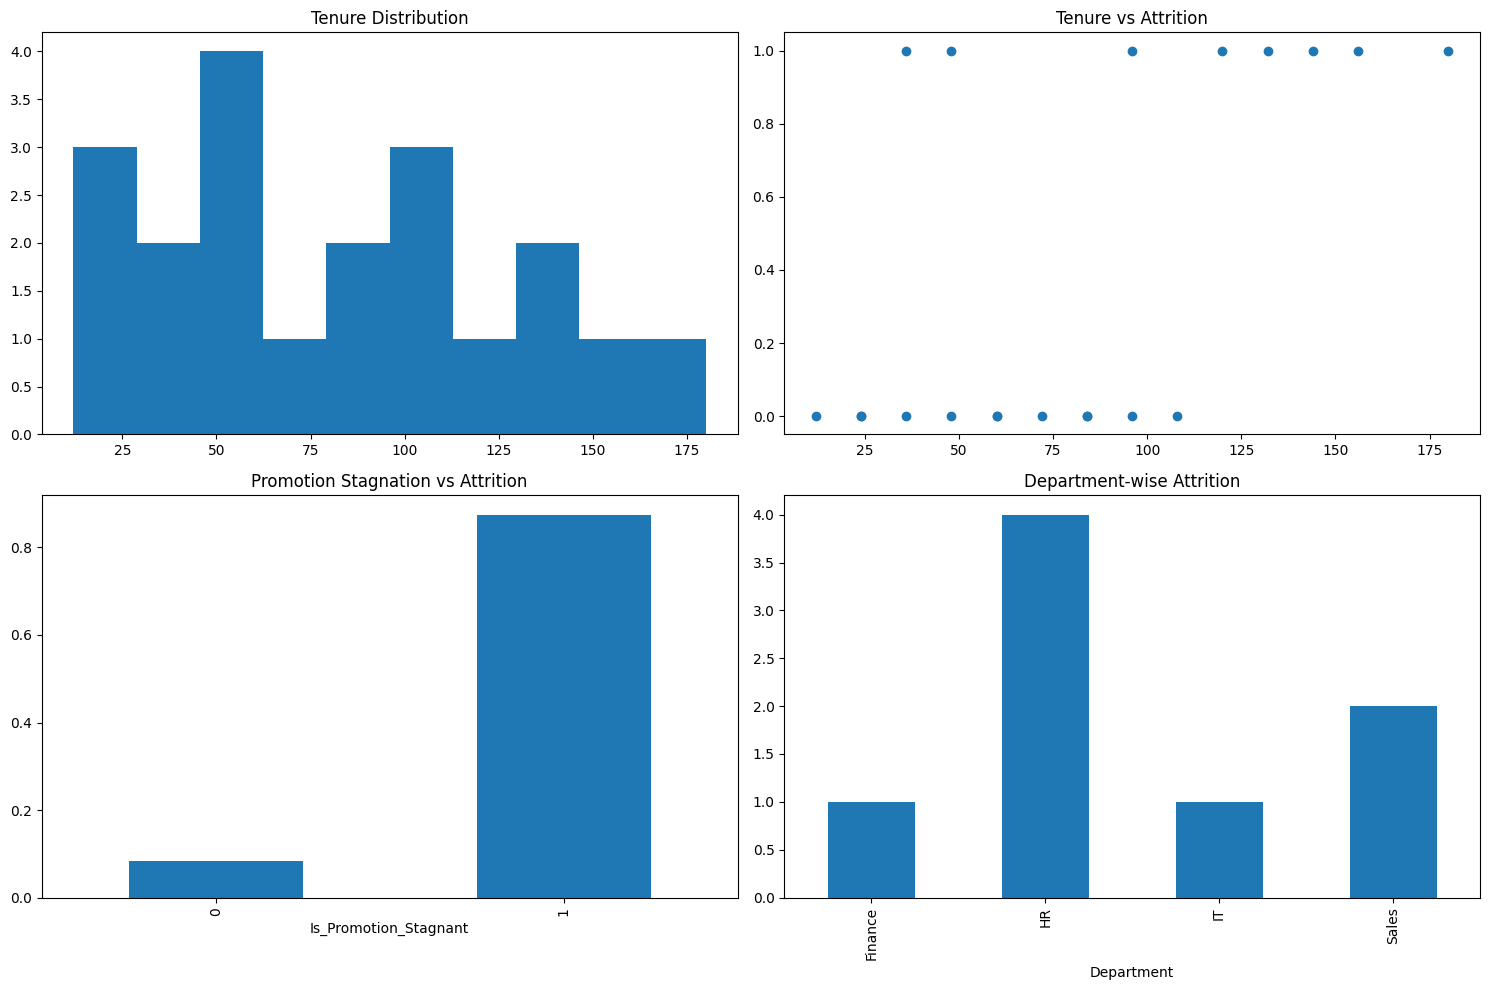

In [6]:
plt.figure(figsize=(15,10))

# 1. Tenure Distribution
plt.subplot(2,2,1)
plt.hist(df["Tenure_Months"], bins=10)
plt.title("Tenure Distribution")

# 2. Tenure vs Attrition
plt.subplot(2,2,2)
plt.scatter(df["Tenure_Months"], df["Attrition"])
plt.title("Tenure vs Attrition")

# 3. Promotion Stagnation vs Attrition
plt.subplot(2,2,3)
df.groupby("Is_Promotion_Stagnant")["Attrition"].mean().plot(kind='bar')
plt.title("Promotion Stagnation vs Attrition")

# 4. Department-wise Attrition
plt.subplot(2,2,4)
df.groupby("Department")["Attrition"].sum().plot(kind='bar')
plt.title("Department-wise Attrition")

plt.tight_layout()
plt.show()